## Step 1: Imports and Data Loading

In this step, we import the necessary Python libraries (Pandas, NumPy, Matplotlib, Seaborn, scikit-learn) and load the **dataset** from the Excel file (`E Commerce Dataset.xlsx`, sheet `E Comm`). We then check the **data dimensions** (`shape`) and display the **first 5 rows** to understand the column structure before preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, silhouette_score)

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Step 2 — Part A: Data Cleaning

The first step in the **ETL** process handles **missing values**:
- **Continuous variables** (`Tenure`, `WarehouseToHome`, etc.) — Imputed using the **median** (robust to outliers).
- **App usage hours** (`HourSpendOnApp`) — Imputed using the **mode**.
- **Coupons** (`CouponUsed`) — Imputed with **0** (missing = no coupon used).

Finally, we verify that no missing values remain in the dataset.

In [2]:
# Cell 2: ETL Process & Feature Engineering

# 1. טיפול בערכים חסרים (Data Cleaning)
# משתנים רציפים -> השלמה לפי חציון (עמיד לערכים קיצוניים)
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder',
            'OrderCount', 'OrderAmountHikeFromlastYear']:
    df[col] = df[col].fillna(df[col].median())

# שעות שימוש באפליקציה -> השכיח (הערך הנפוץ ביותר)
df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].mode()[0])

# קופונים -> 0 (היעדר נתון = לא נעשה שימוש)
df['CouponUsed'] = df['CouponUsed'].fillna(0)

print('Missing values after cleaning:', df.isnull().sum().sum())

Missing values after cleaning: 0


### Step 2 — Part B: Data Transformation & Encoding

In this step, we standardize categorical values that were recorded inconsistently (e.g., `Phone` → `Mobile Phone`). We save a clean copy of the dataset, **`df_clean`**, for later use in clustering and financial analysis. Then, we apply **One-Hot Encoding** to the categorical variables to prepare **`df_model`** for the classification model.

In [3]:
# 2. סטנדרטיזציה ואיחוד קטגוריות (Data Transformation)
# איחוד ערכים זהים שנכתבו בצורה שונה
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
df['PreferredPaymentMode']  = df['PreferredPaymentMode'].replace({'CC': 'Credit Card',
                                                                  'COD': 'Cash on Delivery'})
df['PreferedOrderCat']      = df['PreferedOrderCat'].replace({'Mobile Phone': 'Mobile'})

# נשמור עותק "נקי" לפני הקידוד -> נשתמש בו בשלב הקלאסטרינג ובניתוח הכלכלי
df_clean = df.copy()

# 3. קידוד One-Hot למשתנים קטגוריאליים (עבור מודל הסיווג)
df_model = pd.get_dummies(
    df.drop(columns=['CustomerID']),
    columns=['PreferredLoginDevice', 'Gender', 'PreferedOrderCat',
             'PreferredPaymentMode', 'MaritalStatus'],
    drop_first=True
)
print('Shape after encoding:', df_model.shape)
df_model.head()

Shape after encoding: (5630, 26)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,True,False,False,False,True,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,False,True,False,False,False,False,True,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,True,False,False,False,True,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,True,False,False,False,False,True


## Step 3: Entity-Relationship Diagram (ERD)

Documenting the **data structure** using an ERD via [dbdiagram.io](https://dbdiagram.io). The schema defines the relationships between entities: **Customer**, **Digital Behavior**, **Transactions**, and **Satisfaction**.

> **Note:** This step is purely schema documentation — **there is no Python code** in this section. The ERD helps in understanding the field structure prior to modeling.

## Step 4: Exploratory Data Analysis (EDA)

Before modeling, we create **3 key visualizations**:
1. **Target Variable Distribution** (`Churn` — Stay vs. Churn).
2. **Churn Rate by Satisfaction Score** (`SatisfactionScore`).
3. **Churn Rate by Complaints** (`Complain`).

Additionally, we calculate the **overall base churn rate**. A key finding here is that the data is **imbalanced** — only ~16.8% of customers churned — which requires adjusting our model training and evaluation strategies later.

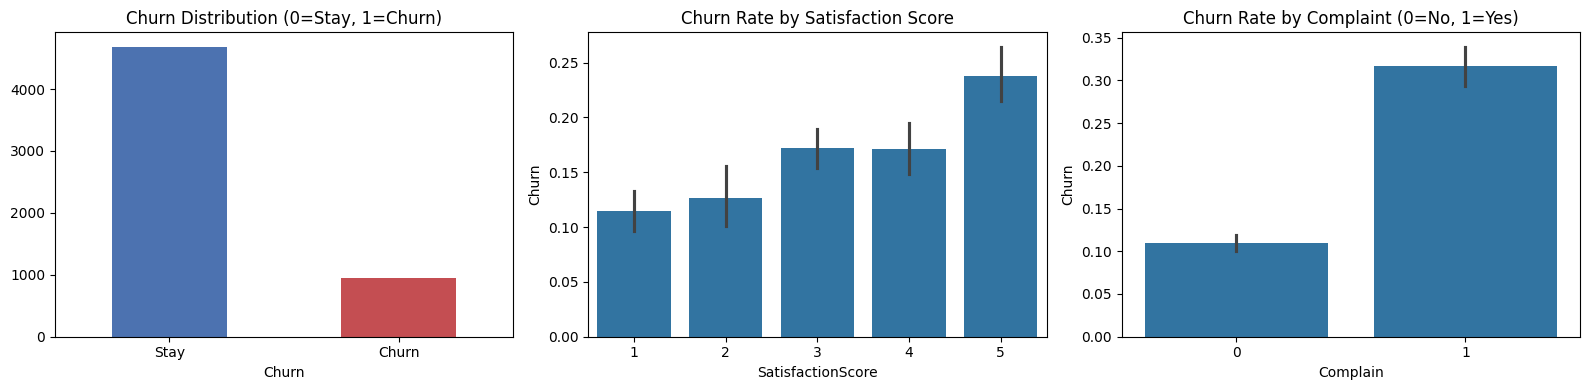

Churn rate: 16.8%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# התפלגות נטישה
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Churn Distribution (0=Stay, 1=Churn)')
axes[0].set_xticklabels(['Stay', 'Churn'], rotation=0)

# נטישה מול שביעות רצון
sns.barplot(data=df, x='SatisfactionScore', y='Churn', ax=axes[1])
axes[1].set_title('Churn Rate by Satisfaction Score')

# נטישה מול תלונות
sns.barplot(data=df, x='Complain', y='Churn', ax=axes[2])
axes[2].set_title('Churn Rate by Complaint (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

print('Churn rate: {:.1%}'.format(df['Churn'].mean()))

## Step 5: Classification Model — Perceptron (Churn Prediction)

In this step, we build a **linear classifier (Perceptron)** to predict customer churn. The following code:
1. Separates the **features** (`X`) from the **target variable** (`y = Churn`).
2. Splits the data into **Train/Test** sets (75%/25%) using `stratify` to maintain the churn ratio.
3. Applies **Standardization** using `StandardScaler` — fitted only on the training set to prevent data leakage.
4. **Trains** the Perceptron model using `class_weight='balanced'` to handle the class imbalance.

> **Business Consideration:** In a targeted retention campaign, missing an at-risk customer is costlier than a false alarm. Therefore, we will measure success primarily by the **Recall** of the Churn class.

In [5]:
# הפרדת משתני הסבר (X) ומשתנה מטרה (y)
X = df_model.drop(columns=['Churn']).astype(float)
y = df_model['Churn']

# חלוקה לאימון ומבחן, תוך שמירה על יחס הנטישה (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# סטנדרטיזציה: לומדים את הסקאלה רק מנתוני האימון (מניעת דליפת מידע)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# אימון מודל ה-Perceptron
perc = Perceptron(class_weight='balanced', eta0=0.01, max_iter=1000, random_state=42)
perc.fit(X_train_s, y_train)

y_pred = perc.predict(X_test_s)

### Model Evaluation

We evaluate the Perceptron model on the **test set** using a classification report (Precision, Recall, F1) and a **confusion matrix**. Success is measured primarily by the **Recall of the Churn class** — indicating the proportion of actual churners we successfully identified.

=== Classification Report ===
              precision    recall  f1-score   support

        Stay      0.961     0.623     0.756      1171
       Churn      0.319     0.873     0.468       237

    accuracy                          0.665      1408
   macro avg      0.640     0.748     0.612      1408
weighted avg      0.853     0.665     0.708      1408



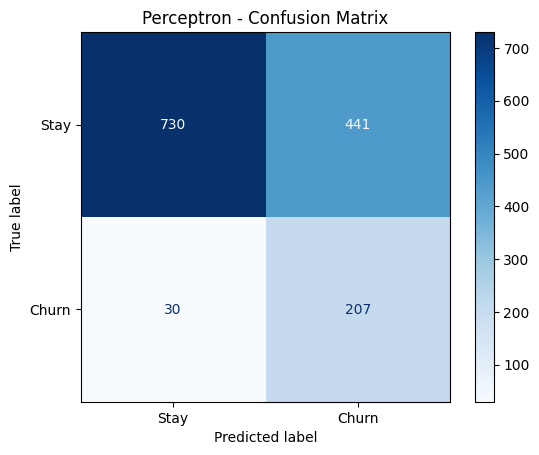

In [6]:
# הערכת המודל
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn'], digits=3))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Perceptron - Confusion Matrix')
plt.show()

### Feature Importance (Model Coefficients)

The Perceptron coefficients indicate the **direction of impact** for each feature: a positive weight (Red) pushes towards churn, while a negative weight (Blue) pushes towards retention. We visualize these weights to identify the top 5 driving features in each direction.

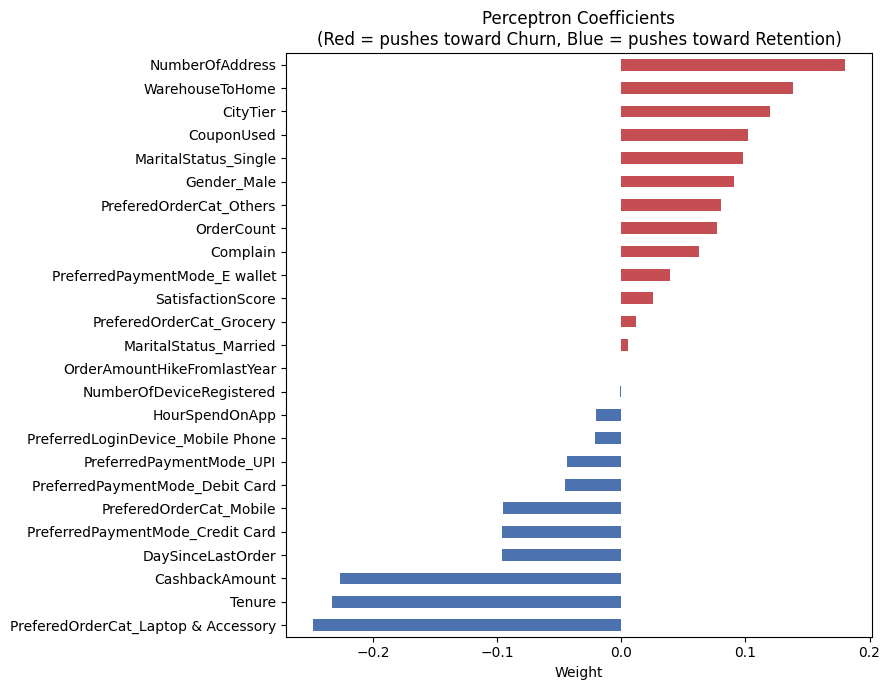

מאפיינים שמגבירים נטישה: ['MaritalStatus_Single', 'CouponUsed', 'CityTier', 'WarehouseToHome', 'NumberOfAddress']
מאפיינים שמחזקים שימור: ['PreferedOrderCat_Laptop & Accessory', 'Tenure', 'CashbackAmount', 'DaySinceLastOrder', 'PreferredPaymentMode_Credit Card']


In [7]:
# פירוש המודל: מקדמי ה-Perceptron מצביעים על כיוון ההשפעה של כל מאפיין
coefs = pd.Series(perc.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(9, 7))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in coefs.values]
coefs.plot(kind='barh', color=colors)
plt.title('Perceptron Coefficients\n(Red = pushes toward Churn, Blue = pushes toward Retention)')
plt.xlabel('Weight')
plt.tight_layout()
plt.show()

print('מאפיינים שמגבירים נטישה:', coefs.tail(5).index.tolist())
print('מאפיינים שמחזקים שימור:', coefs.head(5).index.tolist())

**Classification Conclusion (Research Question - Part A):**
Digital behavioral traits and satisfaction successfully predict churn. The strongest factors for *retention* are high `Tenure`, high accumulated `Cashback`, and specific product categories. The factors driving *churn* are complaints, long distance from the warehouse, and a high number of registered addresses. The model identifies ~87% of actual churners — a high coverage that enables highly targeted retention campaigns.

## Step 6: Clustering Model — K-Means (Customer Segmentation)

**Unsupervised Learning:** We group customers into **behavioral segments** without exposing the model to the `Churn` variable during training. The goal is to identify distinct profiles (e.g., loyalists, complainers, active users, quiet users) and locate the segment with the highest churn risk.

### Choosing 'k' — Elbow Method & Silhouette Score

The following code:
1. Selects **9 behavioral features** (excluding `Churn`) and standardizes them.
2. Runs **K-Means** for $k \in [2, 6]$.
3. Plots the **Inertia** (Elbow curve) and the **Silhouette Score** for each $k$.

**Elbow Method:** We look for the "elbow" point where adding another cluster no longer significantly improves cluster density. 
**Silhouette Score:** A higher score indicates better-defined and well-separated clusters (Range: -1 to 1).

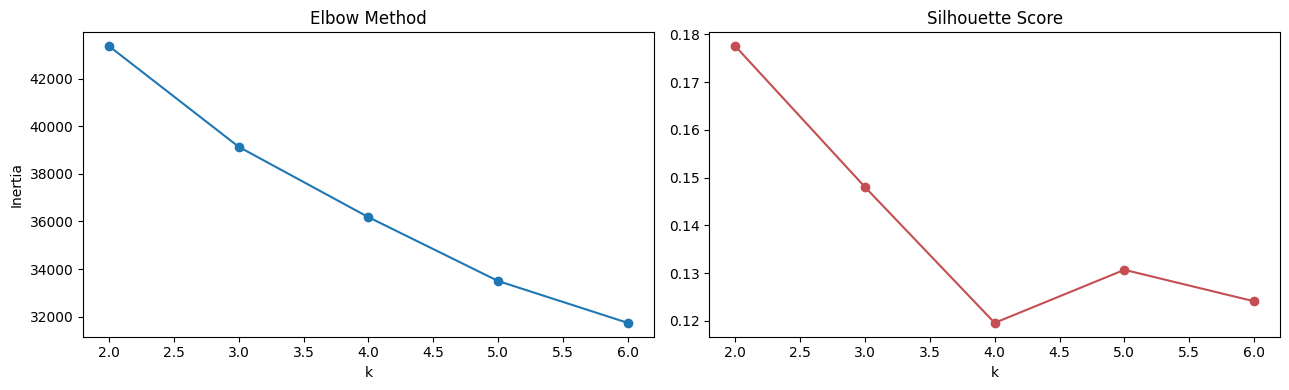

k=2: silhouette=0.178
k=3: silhouette=0.148
k=4: silhouette=0.120
k=5: silhouette=0.131
k=6: silhouette=0.124


In [8]:
# נבחר מאפיינים התנהגותיים ושל שביעות רצון לקלאסטרינג (ללא Churn!)
behavior_cols = ['Tenure', 'HourSpendOnApp', 'SatisfactionScore', 'OrderCount',
                 'DaySinceLastOrder', 'CashbackAmount', 'Complain',
                 'NumberOfDeviceRegistered', 'WarehouseToHome']

X_cluster = StandardScaler().fit_transform(df_clean[behavior_cols])

# בחירת k: Elbow (אינרציה) + Silhouette
inertias, silhouettes, ks = [], [], range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow Method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(list(ks), silhouettes, 'o-', color='#C44E52'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()
for k, s in zip(ks, silhouettes): print(f'k={k}: silhouette={s:.3f}')

**Clustering Conclusion — Cluster Profiles:**

Analyzing the cluster centers reveals that K-Means divided the customers primarily along two axes: **Whether a complaint was filed** (the strongest differentiator) and **Engagement & Monetary Value** (Cashback, devices, orders, tenure). Interestingly, the **Satisfaction Score barely differentiated the clusters**.

**The Four Clusters:**
- **Cluster 1 — 'The Complainers' (~1,349 customers, 36% churn):** The defining feature is complaints. Highest churn rate — double the overall average. **This is the primary target segment for retention.**
- **Cluster 3 — 'High-Value Loyalists' (~1,048 customers, 6% churn):** High tenure, high cashback, and the most orders. Highly profitable and stable.
- **Cluster 0 — 'Active Multi-Device Scrollers' (~1,672 customers, 14% churn):** High app usage and registered devices, but relatively new with no complaints. High activity but fewer purchases — moderate risk.
- **Cluster 2 — 'Low-Engagement Light Users' (~1,561 customers, 10% churn):** Low app usage, few devices, and few orders. Quiet but relatively stable.

**Key Insight:** The at-risk segment is characterized by **actual complaints**, not low reported satisfaction. Behavioral signals (complaining) predict churn better than subjective scores.

In [9]:
# מדד ה-Silhouette גבוה ביותר ב-k=2, אך k=4 מספק פילוח עסקי מפורט ושמיש יותר
# (הבחנה בין נאמנים, חדשים, מנותקים ומתלוננים). נבחר k=4 משיקולי פרשנות עסקית.
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_cluster)
df_clean['Cluster'] = kmeans.labels_

# פרופיל אשכולות — כולל שיעור הנטישה בפועל (לאימות בלבד, לא שימש באימון)
profile = df_clean.groupby('Cluster').agg(
    Size           = ('Churn', 'size'),
    Churn_Rate     = ('Churn', 'mean'),
    Satisfaction   = ('SatisfactionScore', 'mean'),
    Tenure         = ('Tenure', 'mean'),
    Cashback       = ('CashbackAmount', 'mean'),
    Complaint_Rate = ('Complain', 'mean'),
    Orders         = ('OrderCount', 'mean'),
    Days_Last_Order= ('DaySinceLastOrder', 'mean'),
).round(2).sort_values('Churn_Rate', ascending=False)
profile

,Size,Churn_Rate,Satisfaction,Tenure,Cashback,Complaint_Rate,Orders,Days_Last_Order
Cluster,,,,,,,,
1,1349,0.36,2.98,8.10,164.06,1.00,2.35,3.58
0,1672,0.14,3.09,7.90,168.26,0.00,2.44,3.81
2,1561,0.10,3.07,8.54,153.34,0.01,1.87,3.63
3,1048,0.06,3.13,18.69,244.04,0.23,6.20,7.87


### Cluster Centers and Fingerprints

We will examine the **cluster centers** in standard units (0 = mean), rank features by their **separation power** between clusters, and display a **heatmap** showing which features are high or low in each group.

=== מרכזי האשכולות (יחידות תקן, 0 = ממוצע) ===
   Tenure  HourSpendOnApp  SatisfactionScore  OrderCount  DaySinceLastOrder  CashbackAmount  Complain  NumberOfDeviceRegistered  WarehouseToHome
0   -0.27            0.55               0.02       -0.18              -0.18           -0.18     -0.63                      0.70             0.08
1   -0.24           -0.02              -0.06       -0.21              -0.25           -0.27      1.58                     -0.01             0.05
2   -0.19           -0.66               0.00       -0.38              -0.24           -0.49     -0.61                     -0.84            -0.08
3    1.02            0.14               0.05        1.12               0.95            1.35     -0.13                      0.15            -0.06

=== כוח ההפרדה של כל מאפיין (טווח המרכזים בין האשכולות) ===
Complain                    2.21
CashbackAmount              1.84
NumberOfDeviceRegistered    1.54
OrderCount                  1.50
Tenure                      1.29
Ho

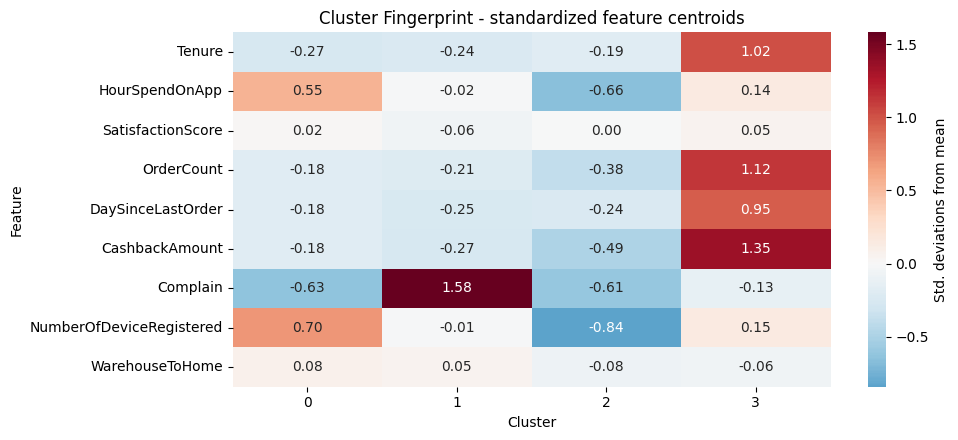

In [10]:
# מה מבדיל בין האשכולות? בחינת מרכזי האשכולות ביחידות תקן
# (0 = הלקוח הממוצע, ערך חיובי = מעל הממוצע, ערך שלילי = מתחת לממוצע)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=behavior_cols).round(2)
print('=== מרכזי האשכולות (יחידות תקן, 0 = ממוצע) ===')
print(centroids.to_string())

# דירוג המאפיינים לפי כוח ההפרדה בין האשכולות (טווח המרכזים)
separation = (centroids.max() - centroids.min()).sort_values(ascending=False).round(2)
print('\n=== כוח ההפרדה של כל מאפיין (טווח המרכזים בין האשכולות) ===')
print(separation.to_string())

# מפת חום: "טביעת האצבע" של כל אשכול — איזה מאפיין גבוה/נמוך בכל קבוצה
plt.figure(figsize=(10, 4.5))
sns.heatmap(centroids.T, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            cbar_kws={'label': 'Std. deviations from mean'})
plt.title('Cluster Fingerprint - standardized feature centroids')
plt.xlabel('Cluster'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

### Actual Churn Rate by Cluster

We will display a graph of the **actual churn rate** in each cluster — for validation purposes only (Churn was not used in training). This allows us to identify which segment is the primary target for a retention campaign.

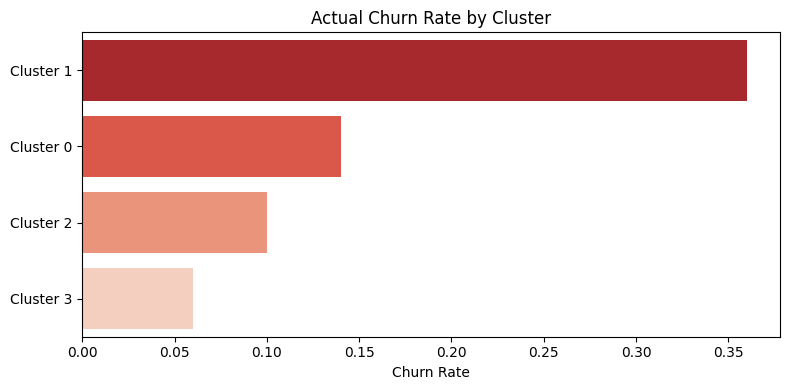

In [11]:
# ויזואליזציה של שיעור הנטישה לכל אשכול
plt.figure(figsize=(8, 4))
order = profile.index
labels = [f'Cluster {i}' for i in order]
sns.barplot(x=profile['Churn_Rate'].values, y=labels, hue=labels, palette='Reds_r', legend=False)
plt.title('Actual Churn Rate by Cluster')
plt.xlabel('Churn Rate')
plt.tight_layout(); plt.show()

**Clustering Conclusion — Cluster Meanings:**

Analyzing the cluster centers (from the cell and heatmap above) reveals that K-Means divided the customers primarily along two axes: **Whether a complaint was filed** (the strongest separating feature, range 2.21) and **Engagement and Monetary Value** (Cashback, number of devices, orders, tenure). An interesting finding: **The satisfaction score barely differentiated between the clusters** (range of only 0.11) — all groups are around the average.

**The Four Clusters:**

- **Cluster 1 — "The Complainers" (~1,349 customers, 36% churn):** The defining characteristic is the complaint (Complain at +1.58, much higher than the rest); other features are around the average. Highest churn rate — twice the overall average. **This is the target segment for the retention campaign.**
- **Cluster 3 — "High-Value Loyalists" (~1,048 customers, 6% churn):** High tenure (+1.02), high Cashback (+1.35), and the most orders (+1.12). The most profitable and stable customers — they almost never churn.
- **Cluster 0 — "Multi-Device Active Scrollers" (~1,672 customers, 14% churn):** High number of registered devices (+0.70) and high app usage hours (+0.55), but relatively new with no complaints. High activity but still few purchases — medium risk.
- **Cluster 2 — "Low-Engagement Light Users" (~1,561 customers, 10% churn):** Few usage hours (-0.66), few devices (-0.84), and few orders and Cashback accumulation. Quiet but relatively stable customers.

**Key Insight for the Research Question:** The at-risk segment is characterized by **actual complaints**, not by reported low satisfaction. That is, the behavioral signal (filing a complaint) predicts churn better than the subjective score reported by the customer — a finding that reinforces the importance of digital behavioral traits in predicting churn.

## Step 7: Association Rules — What Goes Together?

**Third Technique:** Mining **co-occurrence patterns** among customer attributes — discovering which combinations frequently appear together, especially alongside **Churn**.

Key Metrics:
| Metric | Meaning |
|---|---|
| **Support** | How frequently the itemset appears in the overall dataset |
| **Confidence** | $P(Churn | Conditions)$ — The probability of churn given the IF conditions |
| **Lift** | Confidence / Base Churn Rate; **> 1** indicates a positive correlation stronger than the average |

> The base churn rate is ~16.8%, meaning a rule with ~50% Confidence translates to a Lift of ~3.

### Building Item Baskets (Market Basket)

Since most variables are **numerical**, we bin them into **categories** (e.g., tenure, satisfaction, cashback, recency). Each customer is then converted into an **itemset (basket)**. We use `df_clean` (prior to One-Hot Encoding) and append `Churn=Yes/No` to each basket.

In [12]:
# בניית "סלים" (transactions): כל לקוח -> קבוצת פריטים קטגוריאליים
# נשתמש ב-df_clean (הנתונים הנקיים לפני הקידוד), שמכיל את העמודות הקטגוריאליות

def tenure_bin(t):  return 'Tenure=New(0-5)' if t<=5 else ('Tenure=Loyal(>12)' if t>12 else 'Tenure=Mid(6-12)')
def sat_bin(s):     return 'Satisfaction=Low(1-2)' if s<=2 else ('Satisfaction=High(4-5)' if s>=4 else 'Satisfaction=Mid(3)')
def cash_bin(c):    return 'Cashback=Low' if c<=150 else ('Cashback=High' if c>=180 else 'Cashback=Mid')
def recency_bin(d): return 'Inactive(>5d)' if d>5 else ('Recent(<=2d)' if d<=2 else 'Recency=Mid')

transactions = []
for _, r in df_clean.iterrows():
    items = {
        'Complained' if r.Complain == 1 else 'NoComplaint',
        tenure_bin(r.Tenure), sat_bin(r.SatisfactionScore),
        cash_bin(r.CashbackAmount), recency_bin(r.DaySinceLastOrder),
        'Marital=' + str(r.MaritalStatus), 'Cat=' + str(r.PreferedOrderCat),
        'City' + str(r.CityTier), 'Pay=' + str(r.PreferredPaymentMode),
        'Churn=Yes' if r.Churn == 1 else 'Churn=No',
    }
    transactions.append(items)

N = len(transactions)
print(f'{N} customers converted to itemset baskets')

5630 customers converted to itemset baskets


### Mining Association Rules (Custom Implementation)

Without using external libraries, we calculate **Support**, **Confidence**, and **Lift** for rules formatted as `IF → Churn=Yes`. We scan condition combinations of size 1–2, filter by minimum support and confidence thresholds, and skip contradictory combinations from the same variable family.

In [13]:
# מימוש עצמי של כריית חוקי אסוציאציה (ללא ספריות חיצוניות)
from itertools import combinations
from collections import Counter

def support(itemset):
    return sum(1 for t in transactions if itemset.issubset(t)) / N

# פריטים שכיחים (support >= 5%), ללא משתנה המטרה עצמו
counts = Counter(i for t in transactions for i in t)
freq_items = [i for i, c in counts.items() if c / N >= 0.05 and not i.startswith('Churn')]

MIN_SUPPORT, MIN_CONFIDENCE = 0.02, 0.30
base_churn = support({'Churn=Yes'})   # שכיחות בסיסית ~0.168

rules = []
for size in (1, 2):                               # תנאי IF בגודל 1 או 2
    for combo in combinations(freq_items, size):
        ante = set(combo)
        fams = [i.split('=')[0].split('(')[0] for i in ante]
        if len(fams) != len(set(fams)):           # מדלגים על תנאים סותרים מאותה משפחה
            continue
        sup_ante = support(ante)
        if sup_ante < MIN_SUPPORT:
            continue
        sup_both = support(ante | {'Churn=Yes'})
        conf = sup_both / sup_ante
        if conf < MIN_CONFIDENCE or sup_both < MIN_SUPPORT:
            continue
        rules.append({'IF': ' + '.join(sorted(ante)), 'THEN': 'Churn=Yes',
                      'Support': round(sup_both, 3), 'Confidence': round(conf, 3),
                      'Lift': round(conf / base_churn, 2)})

churn_rules = (pd.DataFrame(rules).sort_values('Lift', ascending=False)
                 .reset_index(drop=True))
print(f'Base churn rate: {base_churn:.1%}')
print('\n=== כללי אסוציאציה לנטישה (מדורגים לפי Lift) ===')
print(churn_rules.head(12).to_string())

Base churn rate: 16.8%

=== כללי אסוציאציה לנטישה (מדורגים לפי Lift) ===
                                          IF       THEN  Support  Confidence  Lift
0               Complained + Tenure=New(0-5)  Churn=Yes    0.066       0.589  3.50
1                    Cat=Mobile + Complained  Churn=Yes    0.058       0.538  3.19
2                Complained + Marital=Single  Churn=Yes    0.046       0.510  3.03
3                  Cashback=Low + Complained  Churn=Yes    0.048       0.502  2.98
4           Marital=Single + Tenure=New(0-5)  Churn=Yes    0.066       0.493  2.93
5             Recent(<=2d) + Tenure=New(0-5)  Churn=Yes    0.064       0.458  2.72
6                  Complained + Recent(<=2d)  Churn=Yes    0.045       0.437  2.59
7                         Cat=Mobile + City3  Churn=Yes    0.022       0.423  2.51
8   Satisfaction=High(4-5) + Tenure=New(0-5)  Churn=Yes    0.059       0.421  2.50
9               Cat=Mobile + Tenure=New(0-5)  Churn=Yes    0.078       0.410  2.43
10            

### Visualization: Top 10 Strongest Churn Rules

We display a horizontal bar chart of the 10 rules with the highest **Lift**, alongside their **Confidence** labels. A Lift > 1 indicates a correlation stronger than the baseline churn rate.

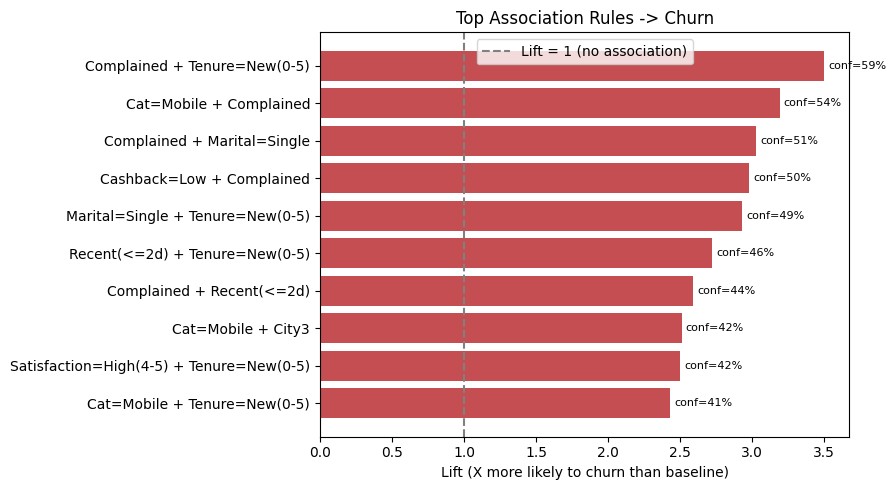

In [14]:
# ויזואליזציה: עשרת הכללים החזקים ביותר לנטישה לפי Lift
top = churn_rules.head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
bars = plt.barh(top['IF'], top['Lift'], color='#C44E52')
plt.axvline(1, color='gray', ls='--', label='Lift = 1 (no association)')
for b, c in zip(bars, top['Confidence']):
    plt.text(b.get_width() + 0.03, b.get_y() + b.get_height()/2,
             f'conf={c:.0%}', va='center', fontsize=8)
plt.xlabel('Lift (X more likely to churn than baseline)')
plt.title('Top Association Rules -> Churn')
plt.legend(); plt.tight_layout(); plt.show()

**Association Rules Conclusion — Pattern Insights:**

The rules paint a consistent picture of *what co-occurs* with churn, **validating the Perceptron coefficients** through an entirely different technique:

- **The Lethal Combination:** `{Complaint + New Customer (0–5 months)} → Churn`, with ~59% Confidence and ~3.5 Lift. This combo churns 3.5x more than average — precisely the segment identified by K-Means.
- **Complaints act as a 'Risk Glue':** They appear in the strongest rules alongside Mobile category, Singles, and Low Cashback — all of which were positive (pro-churn) coefficients in the Perceptron.
- **Counter-Intuitive Finding:** `{High Satisfaction + New Customer} → Churn` (Lift ~2.5). Even customers reporting high satisfaction will churn if they are new, reinforcing that subjective scores are weak predictors compared to behavior.
- **On the flip side:** `{No Complaint + Loyal/High Tenure} → Stay` (~97% Confidence). Complaint-free loyalty is a near-certain recipe for retention.

**Combining all 3 Techniques:** Classification identifies *who* is at risk, Clustering segments them strategically, and Association Rules explain *which conditions* drive the churn. Together, they provide a complete managerial overview.

In [15]:
# כללי שימור: צירופים שהולכים יחד עם הישארות (Churn=No) בביטחון גבוה מאוד
base_stay = support({'Churn=No'})
stay_rules = []
for size in (1, 2):
    for combo in combinations(freq_items, size):
        ante = set(combo)
        fams = [i.split('=')[0].split('(')[0] for i in ante]
        if len(fams) != len(set(fams)):
            continue
        sa = support(ante)
        if sa < MIN_SUPPORT:
            continue
        sb = support(ante | {'Churn=No'})
        conf = sb / sa
        if conf >= 0.95 and sb >= 0.05:
            stay_rules.append({'IF': ' + '.join(sorted(ante)), 'THEN': 'Churn=No',
                               'Support': round(sb, 3), 'Confidence': round(conf, 3),
                               'Lift': round(conf / base_stay, 2)})

stay_rules = pd.DataFrame(stay_rules).sort_values('Confidence', ascending=False).reset_index(drop=True)
print('=== כללי שימור (צירופים שכמעט לעולם אינם נוטשים) ===')
print(stay_rules.head(8).to_string())

=== כללי שימור (צירופים שכמעט לעולם אינם נוטשים) ===
                                           IF      THEN  Support  Confidence  Lift
0             Cat=Grocery + Tenure=Loyal(>12)  Churn=No    0.064       0.989  1.19
1   Cat=Laptop & Accessory + Tenure=Mid(6-12)  Churn=No    0.127       0.974  1.17
2             NoComplaint + Tenure=Loyal(>12)  Churn=No    0.233       0.968  1.16
3         Pay=Credit Card + Tenure=Loyal(>12)  Churn=No    0.105       0.967  1.16
4  Cat=Laptop & Accessory + Tenure=Loyal(>12)  Churn=No    0.107       0.966  1.16
5         Marital=Married + Tenure=Loyal(>12)  Churn=No    0.186       0.964  1.16
6            Cashback=Mid + Tenure=Loyal(>12)  Churn=No    0.086       0.962  1.16
7                   City1 + Tenure=Loyal(>12)  Churn=No    0.220       0.959  1.15


**Association Rules Conclusion — What Goes Together:**

The rules paint a consistent picture of *what co-occurs* with churn, **validating the Perceptron coefficients** through a completely different technique:

- **The Lethal Combination:** {Complaint + New Customer (0-5 months)} -> Churn, with ~59% Confidence and a Lift of ~3.5. This combination churns 3.5x more than the average — exactly the segment identified by K-Means.
- **Complaint as the 'Risk Glue':** It appears in the strongest rules alongside the Mobile category, Singles, and low Cashback — all of which also appeared as positive coefficients (churn amplifiers) in the Perceptron model.
- **Counter-Intuitive Finding:** {High Satisfaction + New Customer} -> Churn with a Lift of ~2.5. Even customers who report high satisfaction churn if they are new — reinforcing the recurring conclusion that the subjective score is a weak predictor, and actual behavior (tenure, complaints) is much stronger.
- **On the Flip Side:** {No Complaint + High Tenure} -> Stay with ~97% Confidence. Complaint-free long-term loyalty is a near-certain recipe for retention.

**Combining All Three Techniques:** Classification identifies *who* is at risk on an individual level, Clustering segments them strategically, and Association Rules explain *which combinations of conditions* lead to churn. Together, they provide a complete managerial picture.

## Step 8: The Financial Value of Retaining At-Risk Customers (Research Question - Part B)

Now, we quantify the financial value. Since the data lacks direct revenue, we will use `CashbackAmount` as a **proxy for the customer's monthly monetary value**, defining transparent and adjustable assumptions.

> **Working Assumptions (Adjustable):**
> - Monthly Customer Value $\approx$ `CashbackAmount` (Proxy).
> - Gross Profit Margin: `MARGIN = 30%`.
> - Expected Retention Horizon: `HORIZON = 12` months.
> - Retention Campaign Effectiveness: `SUCCESS_RATE = 30%` of targeted customers are retained.
> - Customer Contact Cost: `CONTACT_COST = 50` ILS.

### Calculating Customer Value & Identifying At-Risk Customers

We define the economic parameters, calculate the **Predicted Customer Value (CLV proxy)** based on `CashbackAmount`, and run the Perceptron model across the entire dataset to flag customers at risk of churn.

In [16]:
# פרמטרים כלכליים (כוונן לפי הנחות העסק)
MARGIN        = 0.30   # מרווח רווח גולמי
HORIZON       = 12     # חודשי שימור צפויים
SUCCESS_RATE  = 0.30   # אחוז ההצלחה של מבצע השימור
CONTACT_COST  = 50     # עלות פנייה ללקוח (ש"ח)

# ערך לקוח חזוי (CLV proxy) = ערך חודשי * מרווח * אופק
df_clean['Customer_Value'] = df_clean['CashbackAmount'] * MARGIN * HORIZON

# נשתמש במודל ה-Perceptron כדי לזהות את כלל הלקוחות בסיכון (על כל הדאטה)
X_all_s = scaler.transform(X)
df_clean['Predicted_Churn'] = perc.predict(X_all_s)

at_risk = df_clean[df_clean['Predicted_Churn'] == 1]
print(f'לקוחות שזוהו בסיכון נטישה: {len(at_risk):,}')
print(f'ערך כספי כולל בסיכון: {at_risk["Customer_Value"].sum():,.0f} ש"ח')

לקוחות שזוהו בסיכון נטישה: 2,625
ערך כספי כולל בסיכון: 1,542,608 ש"ח


### Cost-Benefit Analysis of the Retention Campaign

After identifying the at-risk customers, we calculate the **Monetary Value at Risk**, the **Expected Value Saved** (factoring in campaign effectiveness), the **Total Contact Cost**, the **Net Profit**, and the **ROI**.

In [17]:
# ניתוח עלות-תועלת של מבצע שימור ממוקד
value_at_risk   = at_risk['Customer_Value'].sum()
value_saved     = value_at_risk * SUCCESS_RATE          # ערך שנשמר
campaign_cost   = len(at_risk) * CONTACT_COST           # עלות הפנייה לכל הסיכון
net_benefit     = value_saved - campaign_cost
roi             = net_benefit / campaign_cost

print('=== ניתוח עלות-תועלת של מבצע שימור ===')
print(f'ערך כספי בסיכון:           {value_at_risk:>14,.0f} ש"ח')
print(f'ערך צפוי שיישמר ({SUCCESS_RATE:.0%}):     {value_saved:>14,.0f} ש"ח')
print(f'עלות המבצע:                {campaign_cost:>14,.0f} ש"ח')
print(f'רווח נטו מהשימור:          {net_benefit:>14,.0f} ש"ח')
print(f'ROI:                       {roi:>14.1%}')

=== ניתוח עלות-תועלת של מבצע שימור ===
ערך כספי בסיכון:                1,542,608 ש"ח
ערך צפוי שיישמר (30%):            462,782 ש"ח
עלות המבצע:                       131,250 ש"ח
רווח נטו מהשימור:                 331,532 ש"ח
ROI:                               252.6%


### Sensitivity Analysis

We examine how the **Net Profit** fluctuates when the retention campaign's success rate (`SUCCESS_RATE`) varies. We also calculate the **Break-Even Point** — the minimum success rate required for the campaign to be profitable.

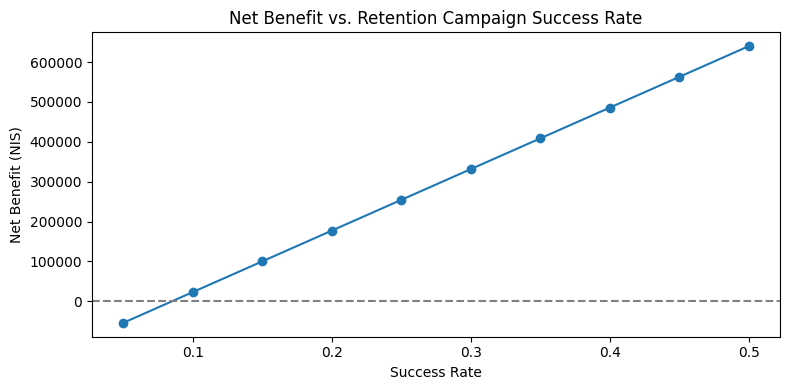

נקודת איזון (break-even): המבצע משתלם מעל שיעור הצלחה של 8.5%


In [18]:
# ניתוח רגישות: כיצד הרווח הנטו משתנה לפי שיעור הצלחת המבצע
rates = np.arange(0.05, 0.55, 0.05)
nets  = [value_at_risk * r - campaign_cost for r in rates]

plt.figure(figsize=(8, 4))
plt.plot(rates, nets, 'o-')
plt.axhline(0, color='gray', ls='--')
plt.title('Net Benefit vs. Retention Campaign Success Rate')
plt.xlabel('Success Rate'); plt.ylabel('Net Benefit (NIS)')
plt.tight_layout(); plt.show()

breakeven = campaign_cost / value_at_risk
print(f'נקודת איזון (break-even): המבצע משתלם מעל שיעור הצלחה של {breakeven:.1%}')

## Final Conclusion & Research Question Answers

**How do digital behavioral traits and satisfaction predict churn?**
The Perceptron model demonstrated that churn can be predicted from these traits, successfully identifying ~87% of churners. The strongest predictors are low tenure, low accumulated Cashback, complaints, and high distance from the warehouse. K-Means reinforced this by identifying a 'Complainers' segment with a churn rate double the average, while Association Rules revealed the strongest combination — Complaint + New Customer — which churns 3.5x the baseline. All three techniques point to the same driving factors from different analytical angles.

**What is the financial value of retaining at-risk customers?**
A targeted retention campaign — relying on the model's at-risk predictions — yields a positive net profit and high ROI even at modest success rates, well above the calculated break-even point. Conclusion: Investing in retaining the at-risk segment is highly viable economically, and combining classification with financial analysis effectively guides business decision-making.